<a href="https://colab.research.google.com/github/aiyman14/Sch-Mgmt-661-Applications-of-AI-Models/blob/main/W5_Improve_Model_Performance_Classifying_Movie_Reviews_shared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCH-MGMT 661: Applications of AI Models  
**Instructor:** Indika Dissanayake  

---

### Tutorial 4: Improve Model Performance

Examples adopted from Chapter 5 of Chollet, F. (2023). Deep Learning with Python (3rd Edition). Manning Publications.

---


**Dataset:** IMDb Movie Reviews Dataset

- 50,000 movie reviews from IMDb.
- Already preprocessed: each review is a list of integers (word indices).
- Reviews are split into:
  - **Training set**: 25,000 reviews (50% positive, 50% negative)
  - **Test set**: 25,000 reviews (50% positive, 50% negative)
- Labels:
  - `0` = Negative review  
  - `1` = Positive review

We’ll limit to the top 10,000 most frequent words to keep things manageable.


## Original Model (Recap from Week 4)

This model is the same one we built in **Week 4**, where we trained a simple neural network on the IMDb movie reviews dataset.  
- Input: vectors of the top 10,000 most frequent words  
- Hidden layers: two Dense layers with 16 units each, using ReLU activation  
- Output: one Dense layer with a sigmoid activation for binary classification (positive vs. negative reviews)  

This baseline gave us a good starting point, but as we saw, it can suffer from **overfitting** and may not generalize well to unseen data.  

 In this week’s tutorial (Week 5), we’ll explore strategies to **improve model performance and reduce overfitting** by adjusting model capacity, adding regularization, and using dropout.


In [1]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from keras.datasets import imdb
import numpy as np


# Load the IMDb dataset (keeping only the top 10,000 most frequent words)
(train_data, train_labels), _ = imdb.load_data(num_words=10000)


# Function to vectorize sequences into one-hot encoded format
# Each review becomes a 10,000-dimensional vector
# Example: review [3, 5, 10] becomes [0, 0, 0, 1, 0, 1, 0, ..., 1, 0]
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results


# Apply vectorization to training data
train_data = vectorize_sequences(train_data)


# Define the model
model = Sequential(
    [
        keras.Input(shape=(10000,)),   # Input layer: vectors of length 10,000
        Dense(16, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"), # Output layer for binary classification
    ]
)


# Compile the model
# - Optimizer: rmsprop (good default for many problems)
# - Loss: binary crossentropy (since it's binary classification)
# - Metric: accuracy
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


# Train the model
# - 20 epochs
# - Batch size: 512
# - Use 40% of training data as validation set
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.6781 - loss: 0.6165 - val_accuracy: 0.8356 - val_loss: 0.4522
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8892 - loss: 0.3702 - val_accuracy: 0.8849 - val_loss: 0.3321
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9223 - loss: 0.2649 - val_accuracy: 0.8784 - val_loss: 0.3075
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9328 - loss: 0.2154 - val_accuracy: 0.8919 - val_loss: 0.2776
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9465 - loss: 0.1788 - val_accuracy: 0.8903 - val_loss: 0.2759
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9555 - loss: 0.1483 - val_accuracy: 0.8863 - val_loss: 0.2823
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9653 - loss: 0.1254 - val_accuracy: 0.8870 - val_loss: 0.2941
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accura

## Adjusting Model Capacity

One way to improve model performance is by adjusting the **capacity** of our network:  
- A **smaller model** may underfit, struggling to capture enough patterns in the data.  
- A **larger model** may overfit, memorizing training data but failing to generalize.  

Let’s experiment by building both **smaller** and **larger** versions of our Week 4 baseline model and compare how they perform.


In [2]:
# Lower capacity (Less number of nodes)

model = Sequential(
    [
        Dense(4, activation="relu"),
        Dense(4, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.6206 - loss: 0.6670 - val_accuracy: 0.7206 - val_loss: 0.5918
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7797 - loss: 0.5674 - val_accuracy: 0.8159 - val_loss: 0.5332
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8499 - loss: 0.5045 - val_accuracy: 0.8637 - val_loss: 0.4745
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8930 - loss: 0.4369 - val_accuracy: 0.8812 - val_loss: 0.4202
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9150 - loss: 0.3719 - val_accuracy: 0.8831 - val_loss: 0.3731
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9238 - loss: 0.3194 - val_accuracy: 0.8807 - val_loss: 0.3395
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9304 - loss: 0.2727 - val_accuracy: 0.8908 - val_loss: 0.3153
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9406 - loss: 0.2362 - val_accuracy: 0.8902 - v

In [3]:
# Higher Capacity

model = Sequential(
    [
        Dense(512, activation="relu"),
        Dense(512, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.6581 - loss: 0.6557 - val_accuracy: 0.8419 - val_loss: 0.3691
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8446 - loss: 0.3544 - val_accuracy: 0.7969 - val_loss: 0.4939
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8861 - loss: 0.2720 - val_accuracy: 0.8622 - val_loss: 0.3315
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9250 - loss: 0.1942 - val_accuracy: 0.8690 - val_loss: 0.3035
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9557 - loss: 0.1246 - val_accuracy: 0.8758 - val_loss: 0.3437
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9650 - loss: 0.1008 - val_accuracy: 0.8809 - val_loss: 0.2959
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9829 - loss: 0.0608 - val_accuracy: 0.8847 - val_loss: 0.3274
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9911 - loss: 0.0397 - val_accuracy: 0.8851 - v

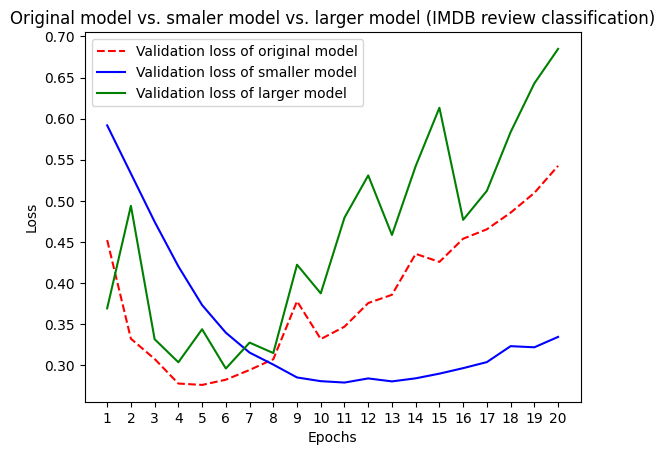

In [4]:
import matplotlib.pyplot as plt


original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "g-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. smaler model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

***Reflection Exercise:***

Look at the training and validation loss curves for the small, medium, and large models.

- Which model shows signs of overfitting?


- If you had to pick one model for real-world use, which would you choose and why?

***Takeaway:***

- A smaller model may have higher training loss, but it often generalizes better(less overfitting).

- A larger model can fit the training data very well, but risks memorizing it instead of learning useful patterns.

- The goal is to find a balance — a model that is complex enough to capture patterns, but not so large that it overfits.

## Adding Weight Regularization

Another way to control overfitting is to apply **regularization**, which discourages the model from relying too heavily on any one feature or weight.  

Here, we’ll apply **L2 regularization**, which keeps weights small and reduces over-complexity in the network.


In [5]:
from keras.regularizers import l2

model = Sequential(
    [
        Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.6955 - loss: 0.6866 - val_accuracy: 0.8432 - val_loss: 0.4869
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8873 - loss: 0.4194 - val_accuracy: 0.8817 - val_loss: 0.3880
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9183 - loss: 0.3293 - val_accuracy: 0.8596 - val_loss: 0.4083
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9198 - loss: 0.3009 - val_accuracy: 0.8875 - val_loss: 0.3574
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9361 - loss: 0.2652 - val_accuracy: 0.8670 - val_loss: 0.3959
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9369 - loss: 0.2549 - val_accuracy: 0.8844 - val_loss: 0.3579
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9454 - loss: 0.2406 - val_accuracy: 0.8854 - val_loss: 0.3620
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9531 - loss: 0.2271 - val_accuracy: 0.8780 - 

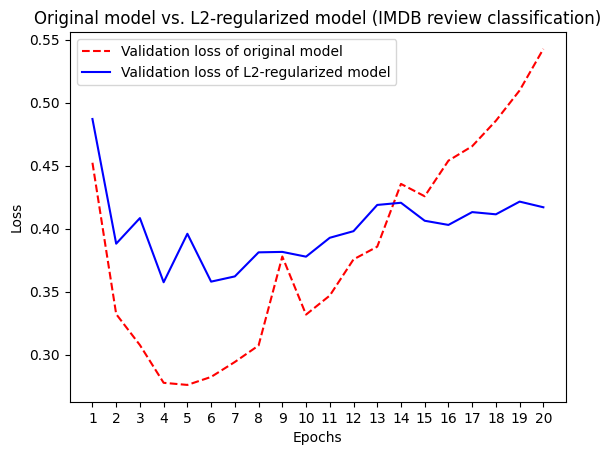

In [6]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

***Reflection Exercise***

Compare the validation loss of the original model and the L2-regularized model.

- Which model appears to overfit faster?

- Does the L2-regularized model show more stable validation loss over time?

- If we had plotted training loss as well, what differences would you expect to see between the two models?

***Takeaways***

- L2 regularization penalizes large weights, which helps keep the model simpler.

- This leads to smoother validation curves and reduces overfitting.

- Even if the training performance of the L2 model is slightly worse (not shown here), the goal is better validation and test performance — generalization matters more than training accuracy.

- Validation plots are a key tool for spotting when regularization is working.

## Using Dropout

**Dropout** is a powerful regularization technique where we randomly “drop” some neurons during training.  

This prevents the network from becoming overly reliant on specific paths and forces it to learn more robust patterns.  
Let’s add Dropout layers to our model and see the effect on validation performance.


In [7]:
from tensorflow.keras.layers import Dropout

model = Sequential(
    [
        Dense(16, activation="relu"),
        Dropout(0.5),
        Dense(16, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.5436 - loss: 0.6797 - val_accuracy: 0.8372 - val_loss: 0.5478
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7111 - loss: 0.5599 - val_accuracy: 0.8714 - val_loss: 0.4167
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7893 - loss: 0.4681 - val_accuracy: 0.8816 - val_loss: 0.3609
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8269 - loss: 0.4188 - val_accuracy: 0.8836 - val_loss: 0.3251
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8677 - loss: 0.3511 - val_accuracy: 0.8787 - val_loss: 0.2996
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8941 - loss: 0.3118 - val_accuracy: 0.8926 - val_loss: 0.2817
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9071 - loss: 0.2814 - val_accuracy: 0.8798 - val_loss: 0.2843
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9199 - loss: 0.2470 - val_accuracy: 0.8933 - 

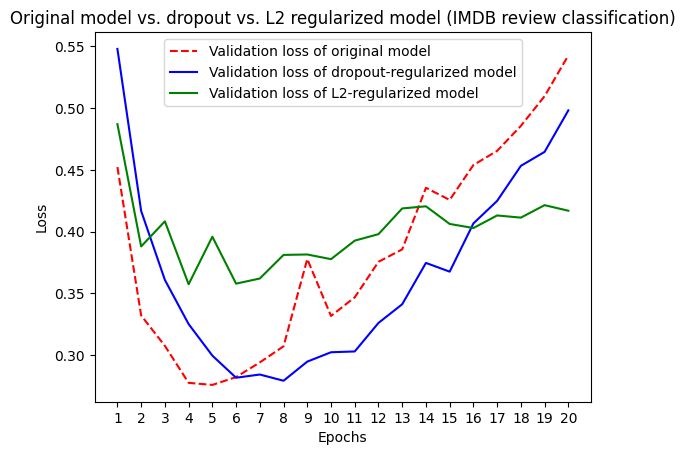

In [8]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]

epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)

plt.plot(
    epochs,
    l2_val_loss,
    "g-",
    label="Validation loss of L2-regularized model",
)

plt.title(
    "Original model vs. dropout vs. L2 regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

***Reflection Exercise***

Look closely at the validation loss curves.

- Does the dropout-regularized model (blue) start to overfit later compared to the original model (red)?

- How does the L2-regularized model (green) behave compared to dropout?

- Which regularization method seems to give a smoother validation curve in this case?



***Takeaways***

- Dropout randomly “drops” units during training, preventing co-adaptation of neurons.

- Dropout typically delays overfitting — validation loss stays lower for longer epochs.

- Both dropout and L2 regularization are tools to improve generalization, but their effects may differ depending on the dataset and model size.

## Combining Dropout and Regularization

Both **L2 regularization** and **dropout** can help fight overfitting — and when used together, they often provide even stronger regularization.  

Let’s combine them and check if performance improves further.


In [9]:
model = Sequential([
    Dense(16, activation="relu", kernel_regularizer=l2(0.002)),
    Dropout(0.5),
    Dense(16, activation="relu", kernel_regularizer=l2(0.002)),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_L2_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.5611 - loss: 0.7658 - val_accuracy: 0.7800 - val_loss: 0.6276
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7346 - loss: 0.6331 - val_accuracy: 0.8744 - val_loss: 0.5239
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8088 - loss: 0.5378 - val_accuracy: 0.8814 - val_loss: 0.4385
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8440 - loss: 0.4844 - val_accuracy: 0.8827 - val_loss: 0.4085
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8749 - loss: 0.4312 - val_accuracy: 0.8877 - val_loss: 0.3744
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8890 - loss: 0.3978 - val_accuracy: 0.8888 - val_loss: 0.3691
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8988 - loss: 0.3724 - val_accuracy: 0.8912 - val_loss: 0.3544
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9133 - loss: 0.3405 - val_accuracy: 0.8871 - 

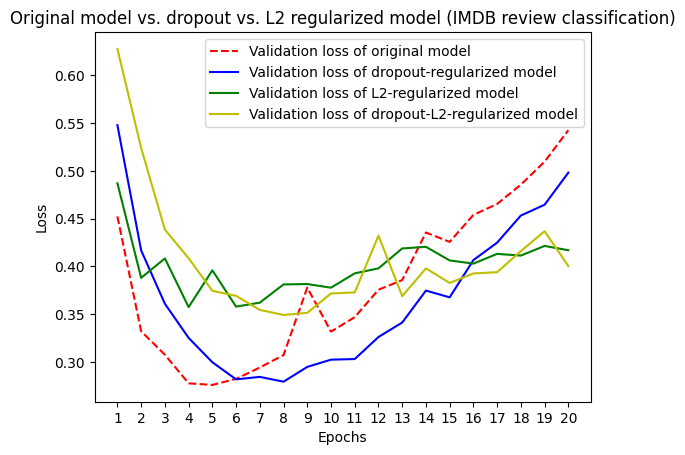

In [10]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
dropout_l2_val_loss = history_L2_dropout.history["val_loss"]

epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)

plt.plot(
    epochs,
    l2_val_loss,
    "g-",
    label="Validation loss of L2-regularized model",
)


plt.plot(
    epochs,
    dropout_l2_val_loss,
    "y-",
    label="Validation loss of dropout-L2-regularized model",
)
plt.title(
    "Original model vs. dropout vs. L2 regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

***Reflection Exercise***

Look closely at the validation loss curves (original, dropout, L2, and dropout+L2):

- Does the combined dropout+L2 model (yellow) actually reduce overfitting more effectively than dropout (blue) or L2 (green) alone?

- Which model appears to provide the best balance between strong early performance and stability over many epochs?

**Takeaways**

- Dropout can push down validation loss in the early epochs but often leads to noisier curves later on.

- L2 regularization tends to produce smoother, more stable curves, even if validation loss doesn’t drop as low early on.

- Combining dropout and L2 doesn’t always outperform using one method alone — trade-offs depend on the dataset and model size.

- In practice, trying both methods (and sometimes both together) is common — the choice depends on whether you value stability (L2) or delayed overfitting (dropout).

In [11]:
# The values printed below represent the average validation loss across all epochs.
# This gives a sense of overall training stability, but it is NOT the standard way
# to select the best model.

print(np.mean(original_val_loss))
print(np.mean(dropout_val_loss))
print(np.mean(l2_val_loss))
print(np.mean(dropout_l2_val_loss))


0.3832167208194733
0.3676169469952583
0.3999092221260071
0.4081153109669685


## Early Stopping

Instead of training for a fixed number of epochs, we can use **early stopping** to monitor validation performance and stop training when the model starts overfitting.  

This helps us save time and avoid ending up with a worse-performing model.


In [12]:
from keras.callbacks import EarlyStopping

# Create an early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',   # Watch validation loss
    patience=2,           # Stop after 2 epochs of no improvement
    restore_best_weights=True  # Optional: revert to the best weights
)


In [13]:
# Original Model
model = Sequential(
    [
        Dense(16, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)



# early_stop object is then passed to the .fit() function

history = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
    callbacks=[early_stop]  # Early stopping callback
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.6901 - loss: 0.5903 - val_accuracy: 0.8718 - val_loss: 0.3813
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8974 - loss: 0.3218 - val_accuracy: 0.8784 - val_loss: 0.3168
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9244 - loss: 0.2332 - val_accuracy: 0.8933 - val_loss: 0.2776
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9436 - loss: 0.1827 - val_accuracy: 0.8925 - val_loss: 0.2743
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9535 - loss: 0.1510 - val_accuracy: 0.8881 - val_loss: 0.2817
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9578 - loss: 0.1314 - val_accuracy: 0.8890 - val_loss: 0.2853


***Reflection Exercise***

- Look at the training logs: how quickly does early stopping halt training compared to the full 20 epochs?

- What advantage do you notice in stopping earlier when validation loss stops improving?

- How does this affect both training time and the risk of overfitting?

***Takeaways***

- Early stopping monitors validation performance and halts training once no further improvement is observed.

- It saves time and prevents overfitting, since training doesn’t continue unnecessarily.

- By restoring the best weights, we ensure the final model is the best version seen during training, not a later, worse one.

- This method is especially useful when we don’t know the “right” number of epochs in advance.

## K-Fold Cross-Validation

So far, we’ve relied on a single **validation split** to check model performance.  
But results can depend heavily on *which* samples end up in the training vs. validation sets.  

**K-fold cross-validation** provides a more reliable estimate of model performance by:  
- Splitting the training data into **K parts** (or “folds”),  
- Training the model **K times**, each time leaving out one fold for validation and using the rest for training,  
- Averaging the validation results across all folds.  

This gives us a more stable and trustworthy evaluation of how well our model will generalize.  


In [14]:
# Define the model-building function

from keras.regularizers import l2
from tensorflow.keras.layers import Dropout

def build_model_1():
    # Model 1: No dropout, no regularization
    model = Sequential([
        Dense(16, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_model_2():
    # Model 2: With dropout and L2 regularization
    model = Sequential([
        Dense(16, activation="relu", kernel_regularizer=l2(0.002)),
        Dropout(0.5),
        Dense(16, activation="relu", kernel_regularizer=l2(0.002)),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [15]:
# Use K-Fold to evaluate peformance of model 1 and model 2
from sklearn.model_selection import KFold

# Track history for each fold
def evaluate_model_with_history(build_function, model_name):
    k = 3
    num_epochs = 20
    all_histories = []

    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    for fold, (train_index, val_index) in enumerate(kfold.split(train_data)):
        print(f"Training {model_name} - Fold {fold + 1}")

        partial_train_data = train_data[train_index]
        partial_train_labels = train_labels[train_index]
        val_data = train_data[val_index]
        val_labels = train_labels[val_index]

        model = build_function()
        history = model.fit(
            partial_train_data, partial_train_labels,
            epochs=num_epochs,
            batch_size=512,
            validation_data=(val_data, val_labels),
            verbose=0
        )
        all_histories.append(history.history)

    return all_histories

# Get histories for both models
print("Evaluating Model 1...")
histories_model1 = evaluate_model_with_history(build_model_1, "Model 1 (No Regularization)")

print("Evaluating Model 2...")
histories_model2 = evaluate_model_with_history(build_model_2, "Model 2 (L2 + Dropout)")

Evaluating Model 1...
Training Model 1 (No Regularization) - Fold 1
Training Model 1 (No Regularization) - Fold 2
Training Model 1 (No Regularization) - Fold 3
Evaluating Model 2...
Training Model 2 (L2 + Dropout) - Fold 1
Training Model 2 (L2 + Dropout) - Fold 2
Training Model 2 (L2 + Dropout) - Fold 3


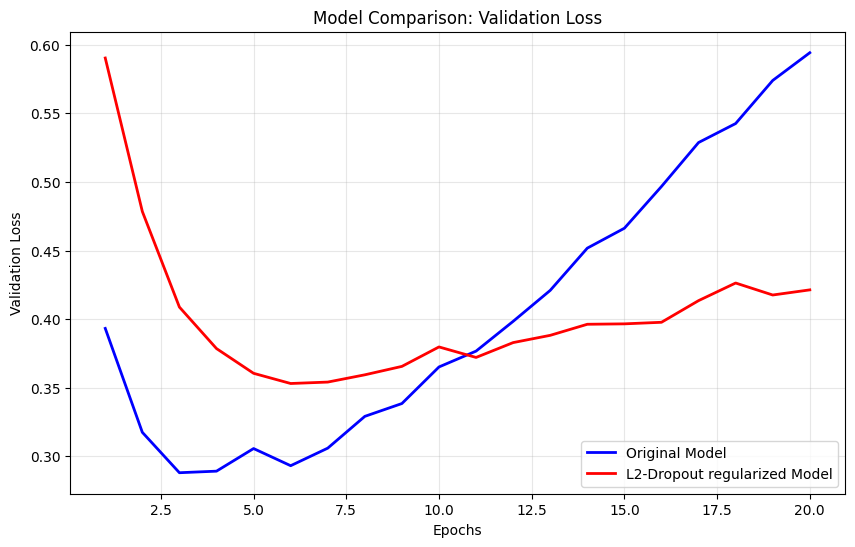

In [16]:
# Simple comparison of average validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs = range(1, 21)
avg_val_loss_model1 = np.mean([history['val_loss'] for history in histories_model1], axis=0)
avg_val_loss_model2 = np.mean([history['val_loss'] for history in histories_model2], axis=0)

plt.plot(epochs, avg_val_loss_model1, 'b-', linewidth=2, label='Original Model')
plt.plot(epochs, avg_val_loss_model2, 'r-', linewidth=2, label='L2-Dropout regularized Model')

plt.title('Model Comparison: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()